# anime_dataset.py使用示例

In [20]:
from anime_dataset import AnimePoseDataset, DatasetConfig, AnimeSkeletonData, AnimeView, AnimeModel
from face5_provider import Face5Provider
from pathlib import Path
import os
from tqdm import tqdm

In [3]:
TEST_WORK_SPACE = Path("./test_workspace")
os.makedirs(TEST_WORK_SPACE, exist_ok=True)

## 初始化整个dataset
实例化一个`AniPoseDataset`对象。

In [4]:
dataset = AnimePoseDataset(
    root=Path("./link-to-anime"),
    config=DatasetConfig(frames_per_view=72)
)

- `model`: 从当前数据集的测试集里获取`/68 model`人物模型目录.你将获取一个被实例化的`AnimeModel`对象。
- `view`: 从当前人物模型目录实例(它是一个的`AnimeModel`对象)中获得view目录对象
-  `sample_frame`: 帧实例，是一个   对象。获得对应帧，以及相应信息。

In [5]:
model = dataset.get_model("test", "color_line_optic_68_80", "68 model")
view = model.get_view("01 visual_view")
sample_frame = view.get_frame(1)

print(sample_frame.uuid)
print(sample_frame.image_path)
print(sample_frame.bbox)
print(sample_frame.keypoints)

[DEBUG] checking split_dir: link-to-anime/train
[DEBUG] skipping non-dir in split_dir: link-to-anime/train/.DS_Store
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/.DS_Store
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/26 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/27 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/28 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/29 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/30 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/31 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/32 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/33 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/34 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/35 model
[D

## 保存原始数据json
- mixamo特征点
- bbox
- 渲染图路径
- 其它元数据

In [6]:
sample_frame.save_json(TEST_WORK_SPACE / "sample_frame_1.json")

### 批量导出
- 位于每个人物模型目录下`exported_data`
- 每个view一个子目录，每个frame对应一个json

models: 100%|██████████| 55/55 [00:45<00:00,  1.21it/s]


✓ 导出完成。失败帧数: 0


## 转换为coco17
- 推理出五个缺失的面部特征点
- 转换为coco17格式

- 实例化一个Face5推理器`provider`
- 推理，并用推理出的5个点把姿态特征点扩张、编辑到coco17标准。
- 转换后的`coco_sample_frame`也是一个` AnimeSkeletonData`实例。

In [9]:
provider = Face5Provider(device="cuda", backend="onnxruntime")


coco_sample_frame: AnimeSkeletonData = sample_frame.to_coco17(strict=True, face5_provider=provider, dataset_root=dataset.root)


coco_sample_frame.face5_info   # "inferred" 或 "Head out of frame" 等


/home/tvem/anaconda3/envs/mmpose/lib/python3.8/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


load /home/tvem/.cache/rtmlib/hub/checkpoints/yolox_m_8xb8-300e_humanart-c2c7a14a.onnx with onnxruntime backend
load /home/tvem/.cache/rtmlib/hub/checkpoints/rtmw-dw-x-l_simcc-cocktail14_270e-384x288_20231122.onnx with onnxruntime backend


2026-04-05 03:48:28.739858766 [W:onnxruntime:, graph.cc:4198 CleanUnusedInitializersAndNodeArgs] Removing initializer '1701'. It is not used by any node and should be removed from the model.
2026-04-05 03:48:28.740377775 [W:onnxruntime:, graph.cc:4198 CleanUnusedInitializersAndNodeArgs] Removing initializer '1706'. It is not used by any node and should be removed from the model.
2026-04-05 03:48:28.740403875 [W:onnxruntime:, graph.cc:4198 CleanUnusedInitializersAndNodeArgs] Removing initializer '1709'. It is not used by any node and should be removed from the model.


'inferred'

In [10]:
coco_sample_frame.save_json(TEST_WORK_SPACE / "coco_sample_frame_1.json")

预览 AnimeSkeletonData 的关键点（支持 mixamo / coco17） ─

In [11]:
FACE5_NAMES = ["nose", "left_eye", "right_eye", "left_ear", "right_ear"]

预览`coco_sample_frame`的各个姿态特征点情况

[DEBUG] sample.uuid       = 6b7b5ac6-dc8a-51b7-96b4-973cc20b5c02
[DEBUG] sample.sample_key = test/color_line_optic_68_80/68 model/01 visual_view/frame_0001
[DEBUG] sample.format     = coco17
[DEBUG] sample.image_path = test/color_line_optic_68_80/68 model/01 visual_view/01_1 Rendering/0001_1.png
[DEBUG] abs_img_path      = link-to-anime/test/color_line_optic_68_80/68 model/01 visual_view/01_1 Rendering/0001_1.png


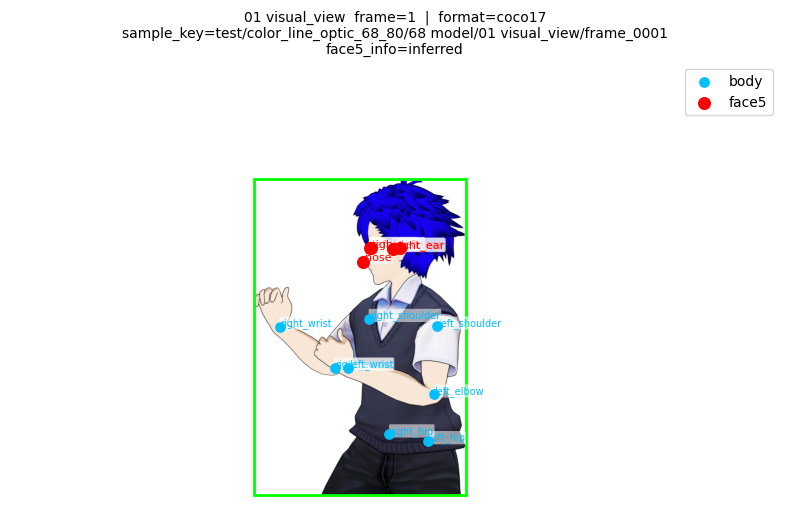

[preview_keypoints] pose_format     : coco17
[preview_keypoints] total keypoints : 17
[preview_keypoints] visible         : 13
[preview_keypoints] face5_info      : inferred


In [12]:
from visualize import  preview_keypoints


preview_keypoints(
    frame_data_instance=coco_sample_frame,
    dataset_root=dataset.root,
    show_labels=True,
    show_invisible=False,
    debug=True,
)

### 批量转换
- 导出在每个人物模型目录下的`export_coco17`下
- 和前面一样，每个view一个子目录(`coco_json_json_out_dir`)，每个frame对应一个json(`coco_json_out_path`)

##  交互式骨骼可视化

In [22]:
import re
from pathlib import Path

first_model = next(dataset.iter_models())
first_view = next(first_model.iter_views())

coco_dir = Path(first_model.model_path) / "exported_coco17" / first_view.view_name

print("_fids 返回值：", )
# 模拟 _fids 逻辑
ids = []
for p in sorted(coco_dir.iterdir()):
    m = re.match(r"frame_(\d{4})_coco17\.json", p.name)
    if m:
        ids.append(int(m.group(1)))
print(f"  扫描到 {len(ids)} 个 frame_id，前5个: {ids[:5]}")
print()

# 看看 _fids 实际返回什么
from visualize import _frame_ids_for_view
result = _frame_ids_for_view(first_view)
print(f"_frame_ids_for_view 返回: {result}")

_fids 返回值：
  扫描到 72 个 frame_id，前5个: [1, 2, 3, 4, 5]

_frame_ids_for_view 返回: []


In [21]:
from visualize import show_skeleton_widget
show_skeleton_widget(dataset)

Output()

## 检查view和某一特定帧的json路径

In [ ]:
FRAME_INDEX = 0


# 诊断单元格
mdl = list(dataset.iter_models())[1]
view = list(mdl.iter_views())[1]

print(f"view.view_name         = {view.view_name}")
print(f"view.coco_json_out_dir = {view.coco_json_out_dir}")

frames = list(view.iter_frames())
f = frames[FRAME_INDEX]  
print(f"\nframe.frame_id           = {f.frame_id}")
print(f"frame.coco_json_out_path = {f.coco_json_out_path}")
print(f"frame.json_out_path      = {f.json_out_path}")

view.view_name         = 02 visual_view
view.coco_json_out_dir = None

frame.frame_id           = 1
frame.coco_json_out_path = link-to-anime/train/color_line_optic_26_45/27 model/exported_coco17/02 visual_view/frame_0001_coco17.json
frame.json_out_path      = link-to-anime/train/color_line_optic_26_45/27 model/exported_data/02 visual_view/frame_0001.json
